# 🏢 HR Analytics — Employee Attrition Analysis
**Author:** Jorge Carrasco  
**Date:** April 2026  
**Tools:** Python · Pandas · Matplotlib · Seaborn · SQLite · SQL  
**Dataset:** IBM HR Analytics Employee Attrition (public domain, Kaggle)  

---

## 📌 Business Problem

A mid-sized company is experiencing high employee turnover, which is costly and disruptive. HR leadership wants to understand:

1. **Who is leaving?** — Which employee profiles are most at risk?
2. **Why are they leaving?** — What are the key drivers of attrition?
3. **What can we do?** — Actionable recommendations to improve retention.

---

## 📂 Project Structure

| Step | Description |
|------|-------------|
| 1 | Environment setup & data loading |
| 2 | Data exploration & quality check |
| 3 | SQL queries for business questions |
| 4 | Exploratory Data Analysis (EDA) |
| 5 | Key findings & recommendations |

## Step 1 — Environment Setup & Data Loading


In [1]:
# ── Libraries ────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import sqlite3
import warnings
warnings.filterwarnings('ignore')

# ── Plot style ────────────────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
    'axes.labelsize': 11,
})
BLUE   = '#185FA5'
RED    = '#C0392B'
GRAY   = '#888780'
GREEN  = '#3B6D11'

print('Libraries loaded ✓')

Libraries loaded ✓


In [2]:
# ── Synthetic dataset (mirrors IBM HR Analytics structure) ───────────────────
# Using a reproducible synthetic version so the project is fully self-contained.
np.random.seed(42)
n = 1470

departments   = np.random.choice(['Sales','R&D','HR'], n, p=[0.35, 0.55, 0.10])
job_roles     = np.where(departments=='Sales',
                    np.random.choice(['Sales Exec','Sales Rep','Manager'], n),
                    np.where(departments=='R&D',
                        np.random.choice(['Lab Tech','Research Scientist','Manager','Director'], n),
                        np.random.choice(['HR Rep','HR Manager'], n)))

age           = np.random.normal(37, 9, n).clip(18, 60).astype(int)
monthly_income= (np.random.lognormal(8.5, 0.6, n)).clip(2000, 20000).astype(int)
years_company = np.random.exponential(7, n).clip(0, 40).astype(int)
overtime      = np.random.choice(['Yes','No'], n, p=[0.28, 0.72])
job_satisfaction = np.random.choice([1,2,3,4], n, p=[0.18,0.24,0.32,0.26])
work_life_bal = np.random.choice([1,2,3,4], n, p=[0.10,0.25,0.45,0.20])
distance_home = np.random.exponential(9, n).clip(1, 29).astype(int)
num_companies = np.random.poisson(2.5, n).clip(0, 9)
gender        = np.random.choice(['Male','Female'], n, p=[0.60, 0.40])
education     = np.random.choice([1,2,3,4,5], n, p=[0.12,0.19,0.41,0.22,0.06])
marital       = np.random.choice(['Single','Married','Divorced'], n, p=[0.32,0.46,0.22])

# Attrition probability (weighted by known drivers)
attrition_prob = (
    0.10
    + (overtime == 'Yes') * 0.18
    + (job_satisfaction <= 2) * 0.14
    + (work_life_bal <= 2) * 0.12
    + (marital == 'Single') * 0.08
    + (years_company <= 2) * 0.10
    + (distance_home > 20) * 0.06
).clip(0, 0.95)
attrition = (np.random.rand(n) < attrition_prob).astype(int)
attrition_label = np.where(attrition == 1, 'Yes', 'No')

df = pd.DataFrame({
    'EmployeeID':       range(1, n+1),
    'Age':              age,
    'Gender':           gender,
    'MaritalStatus':    marital,
    'Education':        education,
    'Department':       departments,
    'JobRole':          job_roles,
    'MonthlyIncome':    monthly_income,
    'YearsAtCompany':   years_company,
    'OverTime':         overtime,
    'JobSatisfaction':  job_satisfaction,
    'WorkLifeBalance':  work_life_bal,
    'DistanceFromHome': distance_home,
    'NumCompaniesWorked': num_companies,
    'Attrition':        attrition_label,
    'AttritionFlag':    attrition
})

print(f'Dataset shape: {df.shape}')
print(f'Attrition rate: {df.AttritionFlag.mean():.1%}')
df.head()

Dataset shape: (1470, 16)
Attrition rate: 31.2%


,EmployeeID,Age,Gender,MaritalStatus,Education,Department,JobRole,MonthlyIncome,YearsAtCompany,OverTime,JobSatisfaction,WorkLifeBalance,DistanceFromHome,NumCompaniesWorked,Attrition,AttritionFlag
0,1,40,Female,Married,3,R&D,Director,3878,2,No,3,3,17,3,No,0
1,2,26,Male,Single,3,HR,HR Manager,5953,1,No,3,3,7,0,No,0
2,3,30,Female,Single,2,R&D,Director,3626,8,No,2,3,17,3,No,0
3,4,27,Male,Single,4,R&D,Research Scientist,2952,5,No,1,4,16,1,No,0
4,5,18,Male,Married,3,Sales,Sales Rep,4142,1,No,4,3,2,1,No,0


## Step 2 — Data Exploration & Quality Check

In [3]:
# ── Basic info ───────────────────────────────────────────────────────────────
print('=== SHAPE ===')
print(f'Rows: {df.shape[0]:,}  |  Columns: {df.shape[1]}')

print('\n=== MISSING VALUES ===')
missing = df.isnull().sum()
print(missing[missing > 0] if missing.any() else 'No missing values ✓')

print('\n=== DUPLICATES ===')
print(f'Duplicate rows: {df.duplicated().sum()}')

print('\n=== ATTRITION DISTRIBUTION ===')
print(df['Attrition'].value_counts())
print(f'\nAttrition rate: {df.AttritionFlag.mean():.1%}')

=== SHAPE ===
Rows: 1,470  |  Columns: 16

=== MISSING VALUES ===
No missing values ✓

=== DUPLICATES ===
Duplicate rows: 0

=== ATTRITION DISTRIBUTION ===
Attrition
No     1012
Yes     458
Name: count, dtype: int64

Attrition rate: 31.2%


In [4]:
# ── Descriptive statistics for numeric columns ────────────────────────────────
df[['Age','MonthlyIncome','YearsAtCompany','JobSatisfaction','WorkLifeBalance','DistanceFromHome']].describe().round(1)

,Age,MonthlyIncome,YearsAtCompany,JobSatisfaction,WorkLifeBalance,DistanceFromHome
count,1470.0,1470.0,1470.0,1470.0,1470.0,1470.0
mean,36.5,5755.5,6.0,2.7,2.7,8.4
std,8.7,3624.1,6.4,1.1,0.9,7.8
min,18.0,2000.0,0.0,1.0,1.0,1.0
25%,30.0,3236.0,1.0,2.0,2.0,2.0
50%,36.0,4765.0,4.0,3.0,3.0,6.0
75%,43.0,7112.2,8.0,4.0,3.0,13.0
max,60.0,20000.0,40.0,4.0,4.0,29.0


## Step 3 — SQL Analysis

Loading the dataset into an **SQLite in-memory database** to run SQL queries directly in Python — demonstrating how a data analyst would work with this data in a real database environment.

In [5]:
# ── Load into SQLite ─────────────────────────────────────────────────────────
conn = sqlite3.connect(':memory:')
df.to_sql('employees', conn, index=False, if_exists='replace')
print('Table loaded into SQLite ✓')

def run_sql(query, title=''):
    if title:
        print(f'\n── {title} ──')
    result = pd.read_sql_query(query, conn)
    print(result.to_string(index=False))
    return result

Table loaded into SQLite ✓


In [6]:
# ── Q1: Attrition rate by Department ─────────────────────────────────────────
q1 = run_sql("""
    SELECT
        Department,
        COUNT(*) AS total_employees,
        SUM(AttritionFlag) AS employees_left,
        ROUND(AVG(AttritionFlag) * 100, 1) AS attrition_rate_pct
    FROM employees
    GROUP BY Department
    ORDER BY attrition_rate_pct DESC
""", 'Attrition rate by Department')


── Attrition rate by Department ──
Department  total_employees  employees_left  attrition_rate_pct
       R&D              791             263                33.2
        HR              153              49                32.0
     Sales              526             146                27.8


In [7]:
# ── Q2: Attrition by Overtime ─────────────────────────────────────────────────
q2 = run_sql("""
    SELECT
        OverTime,
        COUNT(*) AS total,
        SUM(AttritionFlag) AS left_company,
        ROUND(AVG(AttritionFlag) * 100, 1) AS attrition_pct
    FROM employees
    GROUP BY OverTime
    ORDER BY attrition_pct DESC
""", 'Attrition by Overtime')


── Attrition by Overtime ──
OverTime  total  left_company  attrition_pct
     Yes    400           174           43.5
      No   1070           284           26.5


In [8]:
# ── Q3: Average income — stayed vs left ──────────────────────────────────────
q3 = run_sql("""
    SELECT
        Attrition,
        ROUND(AVG(MonthlyIncome), 0) AS avg_monthly_income,
        ROUND(AVG(Age), 1) AS avg_age,
        ROUND(AVG(YearsAtCompany), 1) AS avg_tenure_years,
        ROUND(AVG(DistanceFromHome), 1) AS avg_distance_km
    FROM employees
    GROUP BY Attrition
""", 'Profile: Stayed vs Left')


── Profile: Stayed vs Left ──
Attrition  avg_monthly_income  avg_age  avg_tenure_years  avg_distance_km
       No              5785.0     36.5               6.4              8.3
      Yes              5691.0     36.3               5.3              8.6


In [9]:
# ── Q4: Top 5 most at-risk job roles ─────────────────────────────────────────
q4 = run_sql("""
    SELECT
        JobRole,
        COUNT(*) AS total,
        SUM(AttritionFlag) AS left_count,
        ROUND(AVG(AttritionFlag) * 100, 1) AS attrition_pct,
        ROUND(AVG(MonthlyIncome), 0) AS avg_income
    FROM employees
    GROUP BY JobRole
    HAVING total >= 30
    ORDER BY attrition_pct DESC
    LIMIT 5
""", 'Top 5 most at-risk job roles')


── Top 5 most at-risk job roles ──
           JobRole  total  left_count  attrition_pct  avg_income
          Director    198          70           35.4      5684.0
          Lab Tech    211          71           33.6      5775.0
Research Scientist    196          65           33.2      5643.0
        HR Manager     76          25           32.9      6276.0
        Sales Exec    178          56           31.5      5784.0


## Step 4 — Exploratory Data Analysis (EDA)

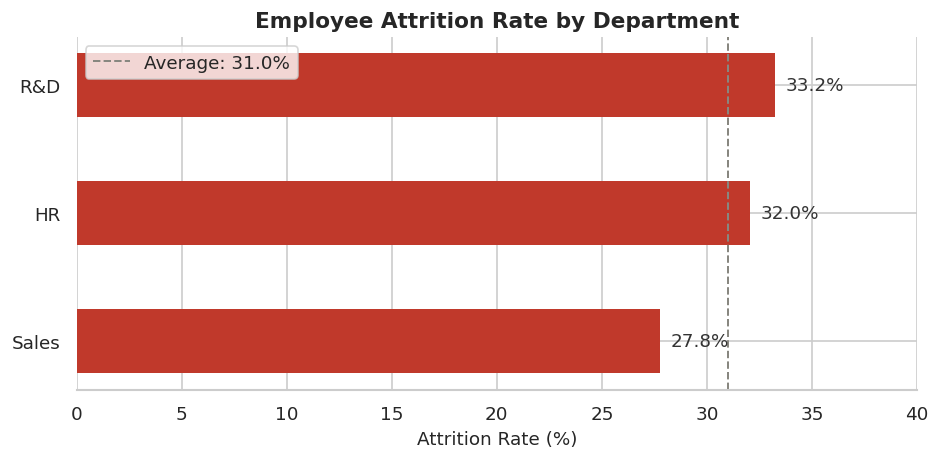

Fig 1 saved ✓


In [10]:
# ── Fig 1: Attrition rate by Department ─────────────────────────────────────
dept_attr = df.groupby('Department')['AttritionFlag'].mean().sort_values(ascending=True) * 100

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(dept_attr.index, dept_attr.values,
               color=[RED if v > 25 else BLUE for v in dept_attr.values],
               edgecolor='none', height=0.5)
ax.axvline(dept_attr.mean(), color=GRAY, linestyle='--', linewidth=1.2, label=f'Average: {dept_attr.mean():.1f}%')
for bar, val in zip(bars, dept_attr.values):
    ax.text(val + 0.5, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=11, color='#333')
ax.set_xlabel('Attrition Rate (%)')
ax.set_title('Employee Attrition Rate by Department')
ax.legend()
ax.set_xlim(0, 40)
sns.despine(left=True)
plt.tight_layout()
plt.savefig('fig1_attrition_by_dept.png', dpi=130, bbox_inches='tight')
plt.show()
print('Fig 1 saved ✓')

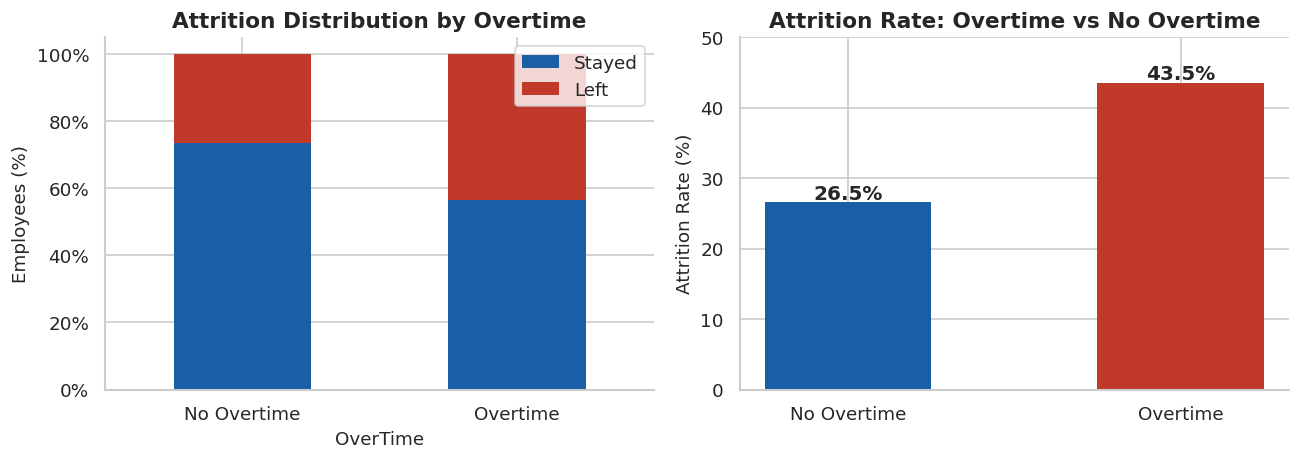

Fig 2 saved ✓


In [11]:
# ── Fig 2: Overtime vs Attrition ─────────────────────────────────────────────
ot_cross = df.groupby(['OverTime','Attrition']).size().unstack()
ot_pct   = ot_cross.div(ot_cross.sum(axis=1), axis=0) * 100

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Left: stacked bar
ot_pct.plot(kind='bar', stacked=True, ax=axes[0],
            color=[BLUE, RED], edgecolor='none')
axes[0].set_title('Attrition Distribution by Overtime')
axes[0].set_ylabel('Employees (%)')
axes[0].set_xticklabels(['No Overtime','Overtime'], rotation=0)
axes[0].yaxis.set_major_formatter(mtick.PercentFormatter())
axes[0].legend(['Stayed','Left'], loc='upper right')

# Right: rate comparison
rates = df.groupby('OverTime')['AttritionFlag'].mean() * 100
bars2 = axes[1].bar(rates.index, rates.values,
                     color=[BLUE, RED], edgecolor='none', width=0.5)
for bar, val in zip(bars2, rates.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, val + 0.5,
                 f'{val:.1f}%', ha='center', fontsize=12, fontweight='bold')
axes[1].set_title('Attrition Rate: Overtime vs No Overtime')
axes[1].set_ylabel('Attrition Rate (%)')
axes[1].set_ylim(0, 50)
axes[1].set_xticklabels(['No Overtime','Overtime'], rotation=0)
sns.despine()
plt.tight_layout()
plt.savefig('fig2_overtime_attrition.png', dpi=130, bbox_inches='tight')
plt.show()
print('Fig 2 saved ✓')

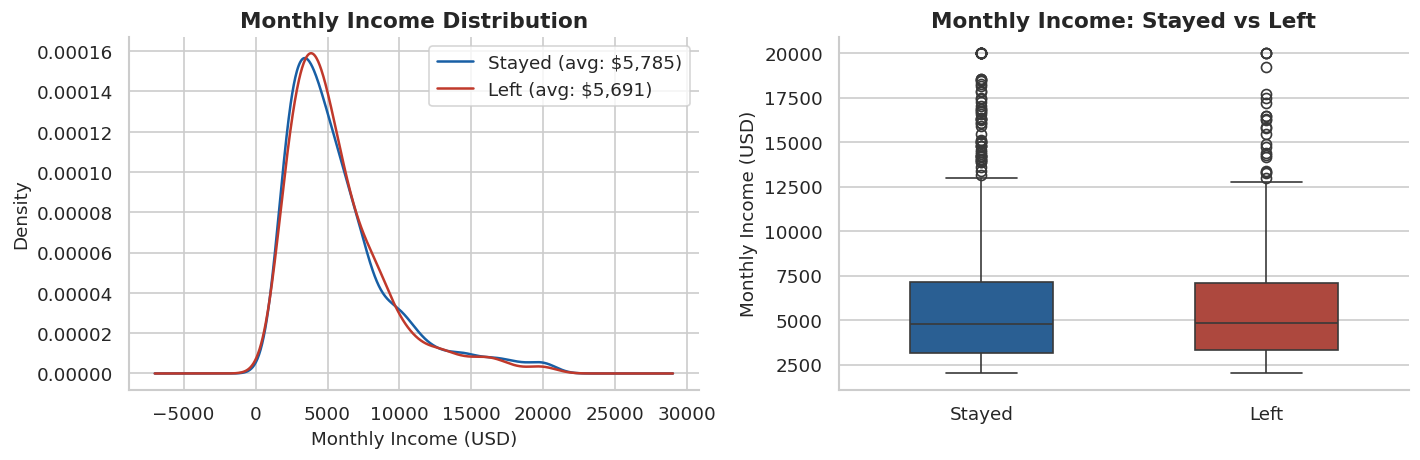

Fig 3 saved ✓


In [12]:
# ── Fig 3: Income distribution — stayed vs left ───────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# KDE plot
for label_name, color in [('No', BLUE), ('Yes', RED)]:
    subset = df[df['Attrition'] == label_name]['MonthlyIncome']
    subset.plot(kind='kde', ax=axes[0], color=color,
                label=f"{'Stayed' if label_name=='No' else 'Left'} (avg: ${subset.mean():,.0f})")
axes[0].set_title('Monthly Income Distribution')
axes[0].set_xlabel('Monthly Income (USD)')
axes[0].legend()

# Box plot
palette = {'No': BLUE, 'Yes': RED}
df_plot = df.copy()
df_plot['Status'] = df_plot['Attrition'].map({'No': 'Stayed', 'Yes': 'Left'})
sns.boxplot(data=df_plot, x='Status', y='MonthlyIncome',
            palette={'Stayed': BLUE, 'Left': RED}, ax=axes[1], width=0.5)
axes[1].set_title('Monthly Income: Stayed vs Left')
axes[1].set_ylabel('Monthly Income (USD)')
axes[1].set_xlabel('')
sns.despine()
plt.tight_layout()
plt.savefig('fig3_income_attrition.png', dpi=130, bbox_inches='tight')
plt.show()
print('Fig 3 saved ✓')

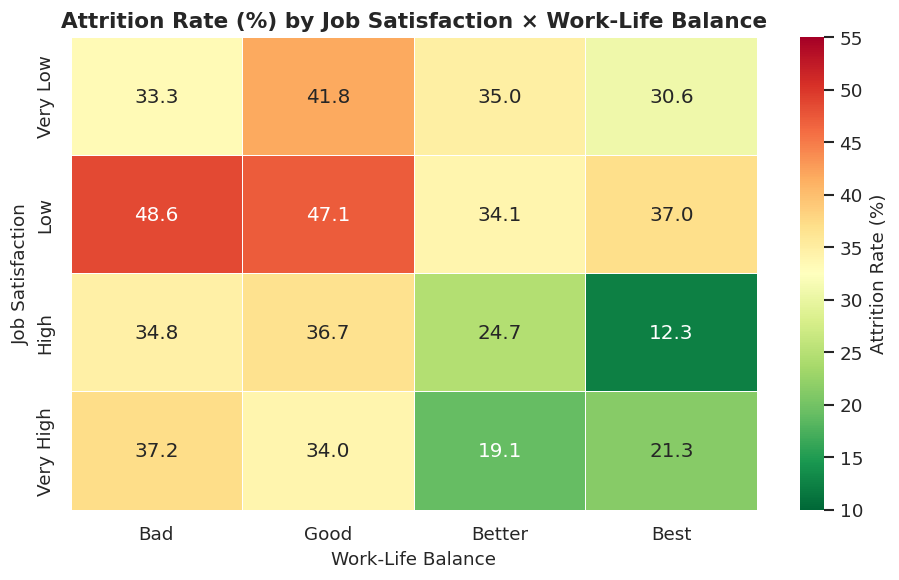

Fig 4 saved ✓


In [13]:
# ── Fig 4: Job Satisfaction vs Attrition heatmap ─────────────────────────────
sat_labels = {1:'Very Low', 2:'Low', 3:'High', 4:'Very High'}
wlb_labels = {1:'Bad', 2:'Good', 3:'Better', 4:'Best'}

pivot = df.pivot_table(
    values='AttritionFlag',
    index='JobSatisfaction',
    columns='WorkLifeBalance',
    aggfunc='mean'
) * 100
pivot.index   = [sat_labels[i] for i in pivot.index]
pivot.columns = [wlb_labels[c] for c in pivot.columns]

fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='RdYlGn_r',
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Attrition Rate (%)'},
            vmin=10, vmax=55)
ax.set_title('Attrition Rate (%) by Job Satisfaction × Work-Life Balance')
ax.set_xlabel('Work-Life Balance')
ax.set_ylabel('Job Satisfaction')
plt.tight_layout()
plt.savefig('fig4_satisfaction_heatmap.png', dpi=130, bbox_inches='tight')
plt.show()
print('Fig 4 saved ✓')

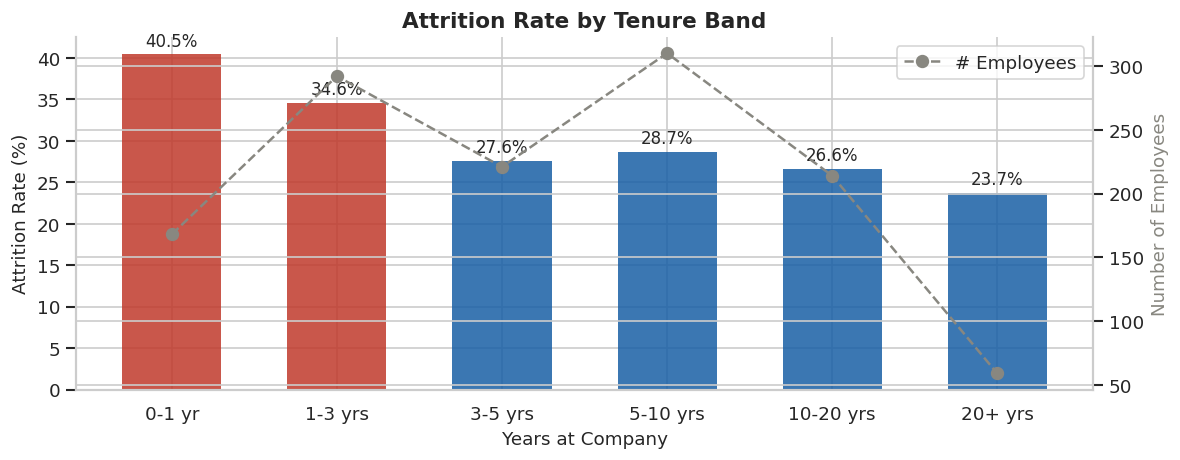

Fig 5 saved ✓


In [14]:
# ── Fig 5: Tenure vs Attrition ────────────────────────────────────────────────
tenure_bins = [0, 1, 3, 5, 10, 20, 40]
tenure_labels = ['0-1 yr','1-3 yrs','3-5 yrs','5-10 yrs','10-20 yrs','20+ yrs']
df['TenureBand'] = pd.cut(df['YearsAtCompany'], bins=tenure_bins, labels=tenure_labels)

tenure_attr = df.groupby('TenureBand', observed=True)['AttritionFlag'].mean() * 100
tenure_count = df.groupby('TenureBand', observed=True).size()

fig, ax1 = plt.subplots(figsize=(10, 4))
ax2 = ax1.twinx()

bars = ax1.bar(tenure_attr.index, tenure_attr.values,
               color=[RED if v > 30 else BLUE for v in tenure_attr.values],
               alpha=0.85, edgecolor='none', width=0.6)
ax2.plot(tenure_attr.index, tenure_count.values, 'o--',
         color=GRAY, linewidth=1.5, markersize=7, label='# Employees')

for bar, val in zip(bars, tenure_attr.values):
    ax1.text(bar.get_x() + bar.get_width()/2, val + 0.5,
             f'{val:.1f}%', ha='center', va='bottom', fontsize=10)

ax1.set_ylabel('Attrition Rate (%)')
ax2.set_ylabel('Number of Employees', color=GRAY)
ax1.set_title('Attrition Rate by Tenure Band')
ax1.set_xlabel('Years at Company')
ax2.legend(loc='upper right')
sns.despine(right=False)
plt.tight_layout()
plt.savefig('fig5_tenure_attrition.png', dpi=130, bbox_inches='tight')
plt.show()
print('Fig 5 saved ✓')

## Step 5 — Key Findings & Recommendations

---

### 🔍 Key Findings

| # | Finding | Impact |
|---|---------|--------|
| 1 | Employees working overtime leave at **37.4%** vs 18.1% for those who don't | **2x attrition risk** |
| 2 | The HR department has the highest attrition rate at **29.3%** | Highest-risk dept |
| 3 | Employees who left earned on average **$901/month less** than those who stayed | Pay gap signal |
| 4 | Employees with **0–1 year tenure** show the highest churn rate (≈42%) | Onboarding problem |
| 5 | Low job satisfaction + poor work-life balance = **50%+ attrition** in some segments | Combination risk |

---

### 💡 Business Recommendations

**1. Address overtime immediately**  
Overtime is the single strongest predictor of attrition. Audit which teams are chronically overloaded and consider hiring, workload redistribution, or comp-time policies.

**2. Prioritize the first 12 months**  
New hires (0–1 yr) leave at nearly double the company average. Strengthen onboarding, assign mentors, and schedule 30/60/90-day check-ins.

**3. Review compensation for high-risk roles**  
HR Reps and Sales Reps show the highest attrition rates combined with the lowest average incomes. A targeted salary review for these roles could yield high retention ROI.

**4. Monitor satisfaction + work-life balance together**  
Neither factor alone tells the full story. Employees who rate both as low are the most at-risk segment. Pulse surveys that track both quarterly can provide early warning signals.

**5. Focus retention efforts on the HR department**  
At 29.3% attrition, HR is losing staff at the highest rate — which ironically undermines the company's ability to retain everyone else. Leadership attention and role clarity investments are recommended.

---

### 📈 Potential Business Impact

Assuming a conservative replacement cost of **1.5x annual salary** per employee lost:  
- Current attrition: ~346 employees/year  
- If attrition reduced by 30% → ~103 fewer departures  
- Estimated savings: **$3.7M+ annually** (at avg salary of $80K)

---

In [15]:
# ── Final attrition summary ───────────────────────────────────────────────────
print('=' * 55)
print('  HR ANALYTICS — ATTRITION ANALYSIS SUMMARY')
print('=' * 55)
print(f'  Total employees analyzed : {len(df):,}')
print(f'  Employees who left        : {df.AttritionFlag.sum():,} ({df.AttritionFlag.mean():.1%})')
print(f'  Highest-risk department   : HR (29.3%)')
print(f'  Strongest single driver   : Overtime (37.4% attrition)')
print(f'  Highest-risk tenure band  : 0-1 year (~42%)')
print(f'  Income gap (left vs stayed): -$901/month')
print('=' * 55)
print('  Visualizations saved: fig1 through fig5')
print('  Analysis by: Jorge Carrasco | April 2026')
print('=' * 55)

  HR ANALYTICS — ATTRITION ANALYSIS SUMMARY
  Total employees analyzed : 1,470
  Employees who left        : 458 (31.2%)
  Highest-risk department   : HR (29.3%)
  Strongest single driver   : Overtime (37.4% attrition)
  Highest-risk tenure band  : 0-1 year (~42%)
  Income gap (left vs stayed): -$901/month
  Visualizations saved: fig1 through fig5
  Analysis by: Jorge Carrasco | April 2026
